In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap

In [2]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.ops.indexing import Vindex
from pyro import poutine

In [3]:
import numpy as np
import math
from itertools import product, accumulate
import einops
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  

In [4]:
def generate_distinct_components(K, V, peak_strength=5.0, base_concent=0.1):
    comps = []
    for k in range(K):
        alpha = torch.ones(V) * base_concent
        alpha[k * V // K] = peak_strength
        comp = torch.distributions.Dirichlet(alpha).sample()
        comps.append(comp)
    return torch.stack(comps)  # shape: (K, V)


In [5]:
def generate_distinct_distributions(N, V, concent=0.8):
    dists = []
    alpha = torch.ones(V) * concent  # sparse
    alpha = torch.clamp(alpha, min=1e-6)
    dist = torch.distributions.Dirichlet(alpha)
    samples = dist.sample((N,))
    return samples


In [6]:
def select_most_diverse(samples, num_select=3):
    """
    samples: (N, D) tensor of N samples with dimension D
    num_select: how many to select
    """
    N = samples.size(0)
    selected = [0]  # start with first sample arbitrarily

    # Compute full pairwise distance matrix (Euclidean)
    # dist[i,j] = ||samples[i] - samples[j]||_2
    diff = samples.unsqueeze(1) - samples.unsqueeze(0)  # (N, N, D)
    dist_matrix = torch.norm(diff, dim=2)  # (N, N)

    for _ in range(num_select - 1):
        # distances from all samples to selected set
        dist_to_selected = dist_matrix[selected, :]  # shape: (len(selected), N)
        min_dist_to_selected, _ = dist_to_selected.min(dim=0)  # min distance to any selected sample

        # Mask out already selected indices by setting distance to -1
        min_dist_to_selected[selected] = -1

        # Pick sample with max min distance
        next_idx = torch.argmax(min_dist_to_selected).item()
        selected.append(next_idx)

    return selected

# Example usage:
samples = torch.distributions.Dirichlet(torch.ones(6)).sample((20,))  # 20 samples from Dirichlet(1)
selected_indices = select_most_diverse(samples, num_select=3)

print("Selected indices:", selected_indices)
print("Selected samples:\n", samples[selected_indices])

Selected indices: [0, 9, 12]
Selected samples:
 tensor([[0.0890, 0.4969, 0.1038, 0.2574, 0.0335, 0.0194],
        [0.0227, 0.1074, 0.0104, 0.0037, 0.8443, 0.0117],
        [0.0078, 0.0655, 0.5615, 0.0392, 0.0768, 0.2491]])


In [7]:
def generate_hierarchical_mixture_data(struct_upbd,
    N_per_base=20, M=200, V=100,  # N_per_base: number of samples per base category
    seed=42
):
    # Config
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base
    torch.manual_seed(seed)

    y_means = torch.linspace(-num_features/4, num_features/4, steps=num_features)
    y_stds = 0.1 + 0.1 * torch.rand(num_features)

    alpha_1 = 0.8
    assert (num_features >= num_base_per_super*num_super)
    super_window = int(num_features/ num_super)
    super_core = generate_distinct_distributions(num_super, super_window, alpha_1)

    row_idx = torch.arange(num_super*super_window).reshape(num_super, super_window)  # (m, k)
    super_prototypes = torch.zeros(num_super, num_features, dtype=super_core.dtype)
    blocks = int(num_features/super_window)
    for i in range(blocks):
        super_prototypes[:, i*super_window:(i+1)*super_window] = super_core * (i == torch.arange(num_super) % blocks).unsqueeze(1)
    super_prototypes = super_prototypes / super_prototypes.sum(dim=-1, keepdim=True)
    
    
    base_prototypes = []
    alpha_2 = [6, 8]
    for super_id in range(num_super):
        candids = generate_distinct_distributions(num_base_per_super*5, num_features, alpha_2[super_id]*super_prototypes[super_id])
        base_prototypes.append(candids[select_most_diverse(candids, num_base_per_super)])
        # base_prototypes.append(generate_distinct_distributions(num_base_per_super, num_features, alpha_2[super_id]*super_prototypes[super_id]))
    base_prototypes = torch.stack(base_prototypes)

    eta=1
    word_dists = generate_distinct_components(num_features, V, base_concent=eta)
    word_block = int(V / (num_super*num_base_per_super))
    overlap = int(word_block/2)
    for i in range(num_features):
        overlap_start = 0
        if (i < int(num_features / 2)):
            non_zero_idxs = torch.arange(i*overlap, i*overlap + word_block)
        else:
            non_zero_idxs = torch.arange(-(i*overlap + word_block)-1, -i*overlap -1)
        mask = torch.zeros(V, dtype=torch.bool)
        mask[non_zero_idxs] = True
        word_dists[i] = word_dists[i]*mask
    word_dists = word_dists / word_dists.sum(dim=-1, keepdim=True)
    X = []
    y = []
    labels_base = []
    labels_super = []
    
    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id*num_base_per_super + base_offset
            base_proto = base_prototypes[super_id][base_offset]
            
            for _ in range(samples_per_base):
                noise = torch.randn(num_features) * 0.1  # local noise around base proto
                doc_dist = base_proto
    
                doc = []
                for word_id in range(M):
                    comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                    word = torch.distributions.Multinomial(1, word_dists[comp_id]).sample()
                    doc.append(word)
                doc = torch.stack(doc)
                
                X.append(doc)
                comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                y.append(torch.normal(mean=y_means[comp_id], std=y_stds[comp_id], size=(1,)))
                labels_base.append(base_id)
                labels_super.append(super_id)
    
    X_data = torch.stack(X)
    y_data = torch.stack(y)
    labels_base = torch.tensor(labels_base)
    labels_super = torch.tensor(labels_super)    

    return {
        "x": X_data,                  # (total_data, M, V)
        "y": y_data,                  # (total_data,)
        "super_labels": labels_super,  # (total_data,)
        "base_labels": labels_base,    # (total_data,)
        "word_dists": word_dists,      # (num_components, V)
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes     # (num_super*num_base_per_super, 
        
    }


In [8]:
struct_upbd = {"G0": 6, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data(struct_upbd)

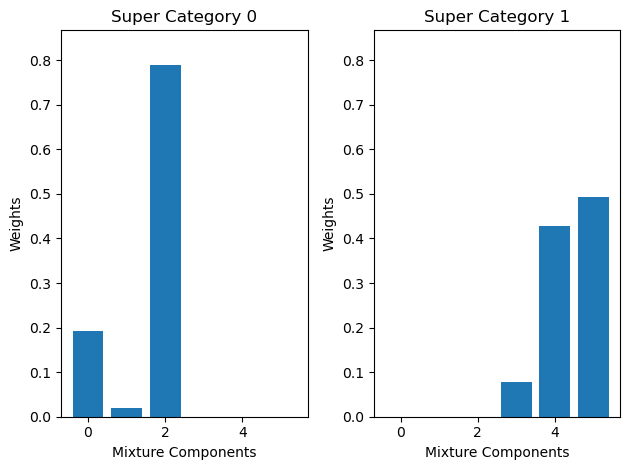

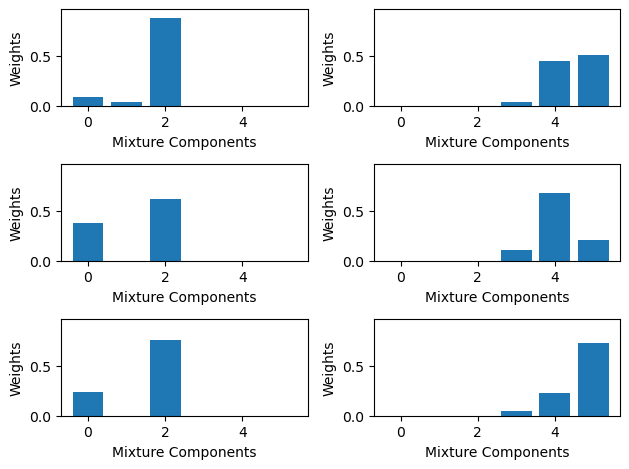

In [9]:
super_mix_weights = data["super_mix_weights"]
child_mix_weights = data["child_mix_weights"]
data = generate_hierarchical_mixture_data(struct_upbd)
fig, axs = plt.subplots(1, struct_upbd["G1"])
for i in range(struct_upbd["G1"]):
    ax = axs[i]
    ax.bar(range(struct_upbd["G0"]), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Super Category Weights of {struct_upbd['G0']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(struct_upbd["G2"], struct_upbd["G1"])
for i in range(struct_upbd["G2"]):
    for j in range(struct_upbd["G1"]):
        ax = axs[i, j]
        ax.bar(range(struct_upbd["G0"]), child_mix_weights[j][i].numpy())
        # ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Child Category Weights of {struct_upbd['G1']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

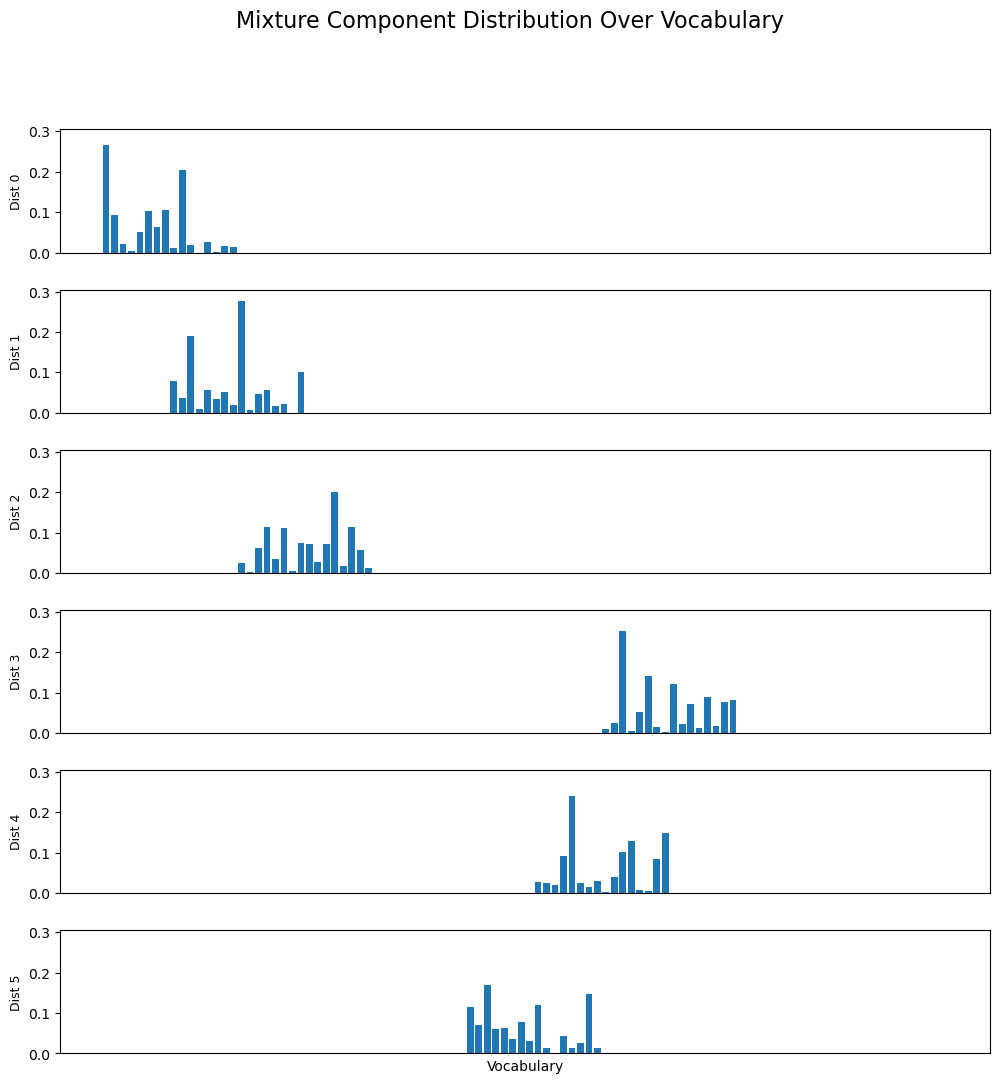

In [10]:
N = struct_upbd["G0"]
V = 100
dists = data["word_dists"]

fig, axs = plt.subplots(N, 1, figsize=(12, 2 * N), sharex=True)  # Share x-axis, increase height

for i in range(N):
    ax = axs[i]
    ax.bar(range(V), dists[i].numpy())
    ax.set_ylabel(f'Dist {i}', fontsize=9)
    ax.set_ylim(0, dists.max().item() * 1.1)

    # Hide x-axis labels except for the last one
    if i < N - 1:
        ax.set_xticks([])
    else:
        ax.set_xlabel("Vocabulary", fontsize=10)

# Tight layout with spacing between plots
fig.suptitle(f"Mixture Component Distribution Over Vocabulary", fontsize=16)
plt.subplots_adjust(hspace=0.3)
plt.show()

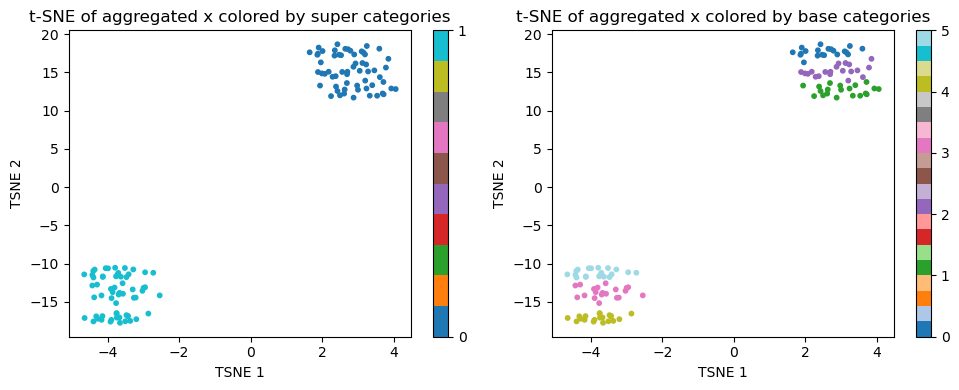

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


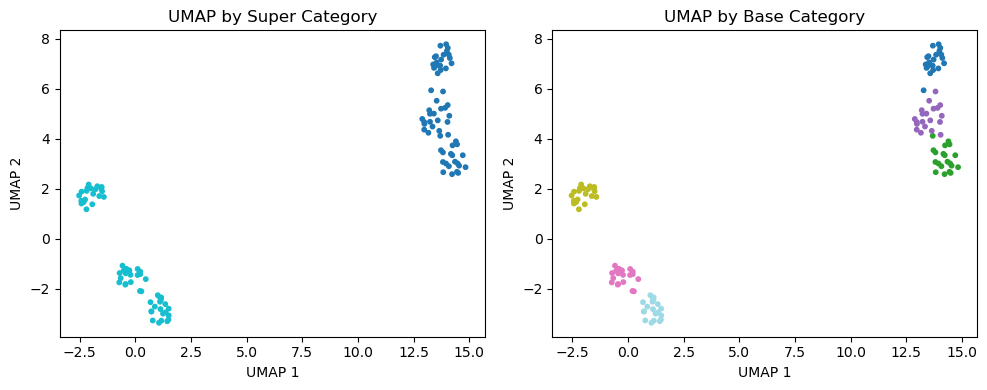

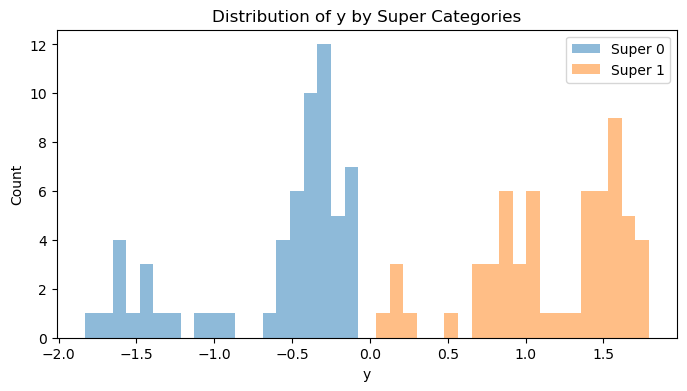

In [11]:
# Run t-SNE
x_agg = data["x"].sum(dim=1)
vocab_size = data["x"].shape[-1]
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg.numpy())

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg.numpy().astype(np.float32))


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(struct_upbd["G1"]):
    y_vals = data["y"][data["super_labels"] == super_id].numpy()
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()



In [12]:
def generalized_einsum(tensor_a, tensor_b):
    # Get shapes
    shape_a = tensor_a.shape  # e.g., (n, a1, a2, a3, a4, ...)
    shape_b = tensor_b.shape  # e.g., (..., k) = (a4, a3, a2, a1, k)
    
    # Extract n (first dimension of A)
    n = shape_a[0]
    
    # Extract additional dimensions from A (excluding n)
    dims_a = list(shape_a[1:])  # e.g., [a1, a2, a3, a4]
    
    # Extract dimensions from B (excluding k)
    dims_b = list(shape_b[:-1])  # e.g., [a4, a3, a2, a1]
    k = shape_b[-1]
    
    # Validate that B's dimensions (excluding k) are the reverse of A's (excluding n)
    if dims_a != dims_b[::-1]:
        raise ValueError(f"Dimensions {dims_a} and {dims_b} are not compatible (must be reverse order)")
    
    # Create dimension labels
    # Use unique letters for each dimension (e.g., i, j, k, l for a1, a2, a3, a4)
    dim_labels = [chr(105 + i) for i in range(len(dims_a))]  # e.g., ['i', 'j', 'k', 'l']
    
    # Pattern for A: n followed by additional dims
    pattern_a = f"a {' '.join(dim_labels)}"  # e.g., "n i j k l"
    
    # Pattern for B: reversed additional dims followed by k
    pattern_b = f"{' '.join(dim_labels[::-1])} z"  # e.g., "l k j i k"
    
    # Output pattern: n k
    pattern_out = "a z"
    
    # Full einsum pattern
    pattern = f"{pattern_a}, {pattern_b} -> {pattern_out}"  # e.g., "n i j k l, l k j i k -> n k"
    
    # Perform einsum
    return einops.einsum(tensor_a, tensor_b, pattern)

In [13]:
def mix_weights(beta):
    # Compute cumulative product of (1 - beta) along the last dimension
    beta1m_cumprod = (1 - beta).cumprod(dim=-1)
    # Pad beta with a 1 at the end of the last dimension
    beta_padded = F.pad(beta, (0, 1), value=1)
    # Pad beta1m_cumprod with a 1 at the start of the last dimension
    beta1m_cumprod_padded = F.pad(beta1m_cumprod, (1, 0), value=1)
    # Element-wise multiplication
    weight = beta_padded * beta1m_cumprod_padded
    rlt = torch.max(weight, torch.tensor(1e-6, device=beta.device))
    rlt = rlt/rlt.sum(dim=-1, keepdim=True)
    # return F.softmax(beta_padded * beta1m_cumprod_padded, dim=-1)
    return rlt
    

In [14]:
@config_enumerate
def model(data, struct_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    
    struct_params = {}
    # dimension: number of mixture
    struct_params["alpha0"] = pyro.param("model_alpha0", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    # dimension: number of mixture
    struct_params["alpha1"] = pyro.param("model_alpha1", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    
    for i in range(2, len(struct_upbd)+1, 1):
        # dimension: level i category * level i-1 category * ... * level 1 category * number of mixture
        struct_params[f"alpha{i}"] = pyro.param(f"model_alpha{i}", torch.rand(param_dims[-i:-1], device=device) , constraint=constraints.positive).unsqueeze(-1).expand(param_dims[-i:])
    # dimension: number of mixture * vocabulary size
    gen_params = pyro.param("model_phi_u", torch.distributions.Dirichlet(torch.ones(vocab_size, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.simplex)
    # dimension: number of mixture * 1
    reg_params_mu = pyro.param("model_phi_y_mu", torch.distributions.Normal(loc = torch.tensor(0.0, device=device), scale = torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )))
    # dimension: number of mixture * 1
    reg_params_sigma = pyro.param("model_phi_y_sigma", torch.distributions.Uniform(torch.tensor(1e-3, device=device), torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.positive)

    struct_weights = {}
    # dimension: number of mixture
    beta_0 = pyro.sample("G0", dist.Beta(torch.ones([struct_upbd["G0"]], device=device), struct_params["alpha0"]).to_event(1))
    # dimension: number of mixture
    struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
    for level in range(1, len(struct_upbd), 1):
        struct_weights["G0"] = struct_weights["G0"].flatten()
        # dimension: level level category * level level-1 category * ... * level 1 category * number of mixture
        param_alpha = struct_params[f"alpha{level}"]*struct_weights[f"G{level-1}"]
        # print(struct_params[f"alpha{level}"].shape, struct_weights[f"G{level-1}"].shape)
        # print(f"level {level}, alpha shape {param_alpha.shape}")

        param_beta = struct_params[f"alpha{level}"]*(1 - struct_weights[f"G{level-1}"].cumsum(-1))
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
        # print(f"next level {beta.shape}")
        struct_weights[f"G{level}"] = mix_weights(beta)[..., :-1]

    assign_prior = {}
    # dimension: number of level - 1
    etas = torch.distributions.Gamma(torch.tensor(1.0, device=device), torch.tensor(1.0, device=device)).sample((len(struct_upbd)-1,))
    for level in range(1, len(struct_upbd), 1):
        params_shape = param_dims[-level-1:-1]
        params_shape.reverse()
        # dimension: level 1 category * level 2 category * ... * level level category
        assign_prior[f"LoZ{level}"] = pyro.param(f"model_LoZ{level}", torch.distributions.Dirichlet(torch.ones(struct_upbd[f"G{level}"], device=device)).sample(params_shape[:-1]), constraint=constraints.simplex)

    feature = data[0].to(device)
    if data[1] is not None:
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    assigned_zs = [torch.tensor([0], device=device).expand(N)]
    
    with pyro.plate("Data", N):
        for level in range(1, len(struct_upbd), 1):
            parent_z = assigned_zs[-1]
            param = assign_prior[f"LoZ{level}"].unsqueeze(0)[assigned_zs[:]]
            assigned_zs.append(pyro.sample(f"z{level}", dist.Categorical(param)))

        assigned_zs.reverse()
        weights_prior = struct_weights[f"G{len(struct_upbd)-1}"][assigned_zs[:-1]]
        concentrate = struct_params[f"alpha{len(struct_upbd)}"][assigned_zs[:-1]]

        topic_dist = pyro.sample("g", dist.Dirichlet(concentrate*weights_prior))
        reg_dists = dist.Normal(reg_params_mu.expand(N, struct_upbd["G0"]), reg_params_sigma.expand(N, struct_upbd["G0"]))
        reg_mix = dist.Categorical(topic_dist)
        pyro.sample("y", dist.MixtureSameFamily(reg_mix, reg_dists), obs=label)
        # print("topic", topic_dist.shape)

        topic_over_docs = topic_dist.unsqueeze(1).expand(-1, M, -1)
        z = pyro.sample(f"z{len(struct_upbd)}", dist.Categorical(probs=topic_over_docs).to_event(1))
        # print(z.shape)

        # Sample observed words from selected topics
        word_dists = gen_params[z]  # shape: (D, N, V)
        # print(word_dists.shape)
        pyro.sample("u", dist.Multinomial(1, probs=word_dists).to_event(1), obs=feature)

In [15]:
def guide(data, struc_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_alpha = pyro.param("guide_beta_0_alpha", init, constraint=constraints.positive)
    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_beta = pyro.param("guide_beta_0_beta", init, constraint=constraints.positive)
    beta_0 = pyro.sample("G0", dist.Beta(q_beta_0_alpha, q_beta_0_beta).to_event(1))
    for level in range(1, len(struct_upbd), 1):
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_alpha = pyro.param(f"guide_beta_{level}_alpha", init, constraint=constraints.positive)
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_beta = pyro.param(f"guide_beta_{level}_beta", init, constraint=constraints.positive)
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        
    feature = data[0].to(device)
    if (data[1] is not None):
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    # Guide only for the continuous latent variable: g
    # Variational parameters for Dirichlet over topic_dist
    g_concentration = pyro.param("guide_g_concentration", torch.ones((N, struct_upbd["G0"]), device=device),
                                 constraint=constraints.positive)

    
    with pyro.plate("Data", N):
        # for level in range(1, len(struct_upbd), 1):
        #     z_param = pyro.param(f"z_param{level}", torch.rand((N, struct_upbd[f"G{level}"]), device=device), constraint=constraints.simplex)
        #     pyro.sample(f"z{level}", dist.Categorical(z_param))
        pyro.sample("g", dist.Dirichlet(g_concentration))


In [16]:
def set_requires_grad_by_prefix(prefix, requires_grad):
    for name, param in pyro.get_param_store().items():
        if name.startswith(prefix) and param.is_leaf:
            param.requires_grad = requires_grad


🔁 Round 1 / 10
📌 Optimizing guide...


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 0, loss = 162500.02


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 100, loss = 158368.58
  [Guide] Step 200, loss = 156249.69
  [Guide] Step 300, loss = 154093.95
  [Guide] Step 400, loss = 150084.06
📌 Optimizing model...
  [Model] Step 0, loss = 147743.67
  [Model] Step 100, loss = 147228.88
  [Model] Step 200, loss = 145053.64
  [Model] Step 300, loss = 143804.42
  [Model] Step 400, loss = 141749.61

🔁 Round 2 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 140170.83
  [Guide] Step 100, loss = 139629.78
  [Guide] Step 200, loss = 137927.25
  [Guide] Step 300, loss = 136789.06
  [Guide] Step 400, loss = 135713.91
📌 Optimizing model...
  [Model] Step 0, loss = 134666.48
  [Model] Step 100, loss = 133138.30
  [Model] Step 200, loss = 133100.39
  [Model] Step 300, loss = 132011.14
  [Model] Step 400, loss = 131097.45

🔁 Round 3 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 130878.61
  [Guide] Step 100, loss = 129971.91
  [Guide] Step 200, loss = 128915.27
  [Guide] Step 300, loss = 128464.49
  [Guide] Step 400, loss = 127640.39


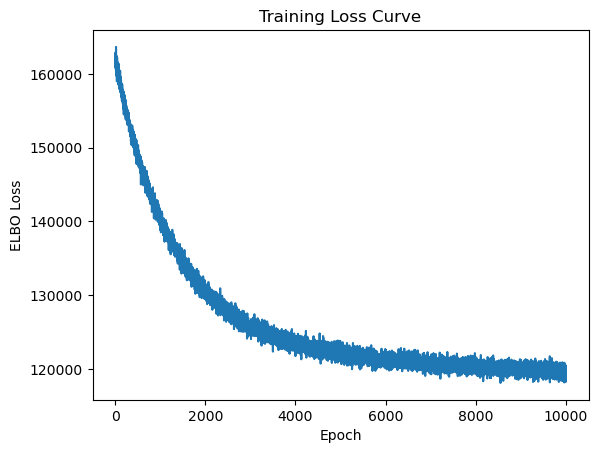

In [17]:

dataset = (data["x"].to(torch.float32), data["y"].view(-1))

device = torch.device("cpu")
# Training settings
num_epochs = 1000
log_every = 100
lr = 1e-3

# Set up optimizer and ELBO
optim = pyro.optim.Adam({"lr": lr})

elbo = TraceEnum_ELBO(max_plate_nesting=1)
svi = SVI(model, guide, optim, loss=elbo)

# === Alternating training loop ===
num_rounds = 10
posterior_steps = 500
model_steps = 500
losses = []

for seed in range(0, 400, 100):
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

    # for epoch in range(num_epochs):
    #     pyro.clear_param_store()
    #     loss = svi.step(dataset, struct_upbd, vocab_size, device)
        
    #     losses.append(loss)
        
    #     if epoch % log_every == 0:
    #         print(f"Epoch {epoch:04d}  Loss: {loss:.4f}")
    #         optim.set_state({"lr": lr/(epoch+1)})
    for round_idx in range(num_rounds):
        print(f"\n🔁 Round {round_idx + 1} / {num_rounds}")
    
        # Phase 1: Guide (Posterior inference)
        set_requires_grad_by_prefix("model_", False)
        set_requires_grad_by_prefix("guide_", True)
        print("📌 Optimizing guide...")
        for step in range(posterior_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Guide] Step {step}, loss = {loss:.2f}")
    
        # Phase 2: Model (Generative parameter update)
        set_requires_grad_by_prefix("guide_", False)
        set_requires_grad_by_prefix("model_", True)
        print("📌 Optimizing model...")
        for step in range(model_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Model] Step {step}, loss = {loss:.2f}")
    # Optional: plot loss
    try:
        import matplotlib.pyplot as plt
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("ELBO Loss")
        plt.title("Training Loss Curve")
        plt.show()
    except ImportError:
        pass
    break



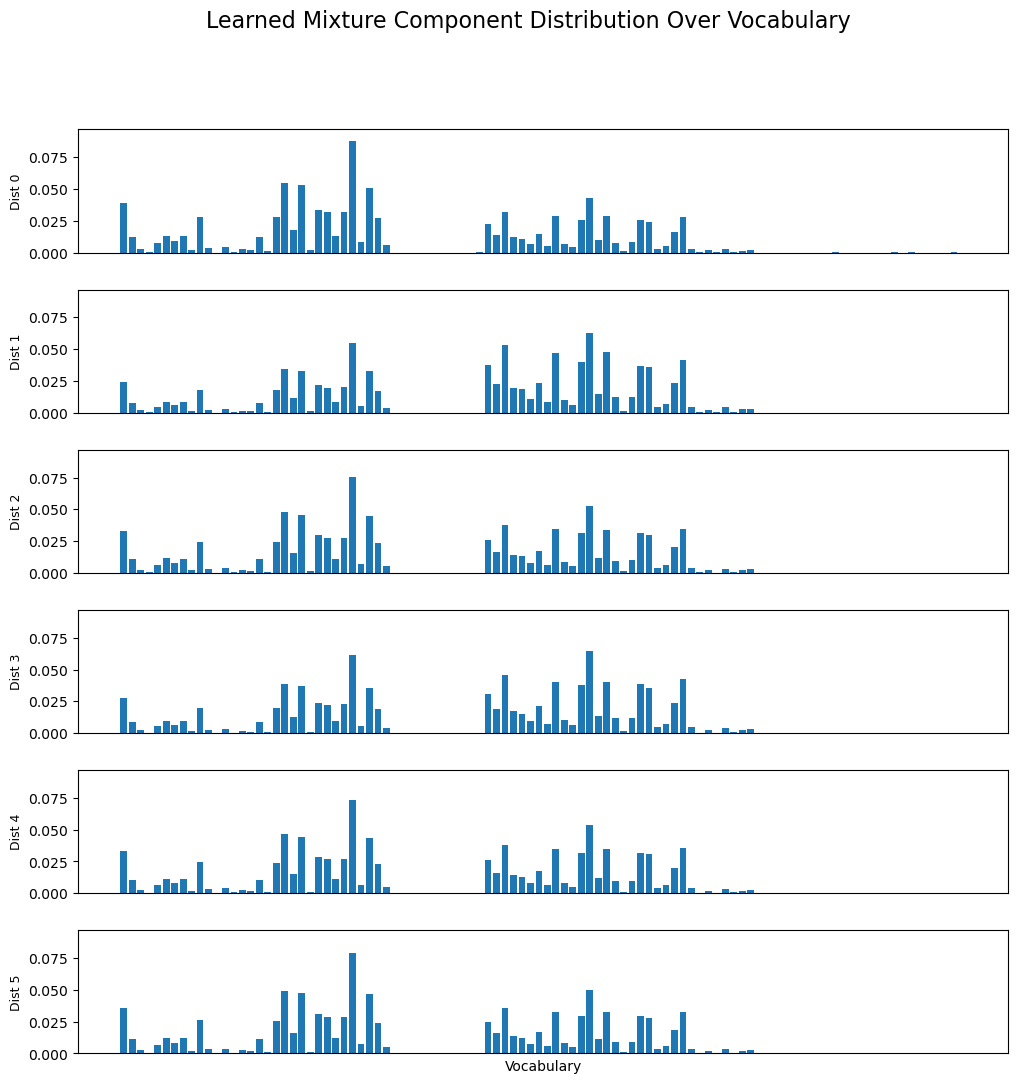

In [24]:
N = struct_upbd["G0"]
dists = pyro.get_param_store().get_param("model_phi_u").detach()

fig, axs = plt.subplots(N, 1, figsize=(12, 2 * N), sharex=True)  # Share x-axis, increase height

for i in range(N):
    ax = axs[i]
    ax.bar(range(params.size(1)), dists[i].numpy())
    ax.set_ylabel(f'Dist {i}', fontsize=9)
    ax.set_ylim(0, dists.max().item() * 1.1)

    # Hide x-axis labels except for the last one
    if i < N - 1:
        ax.set_xticks([])
    else:
        ax.set_xlabel("Vocabulary", fontsize=10)

# Tight layout with spacing between plots
fig.suptitle(f"Learned Mixture Component Distribution Over Vocabulary", fontsize=16)
plt.subplots_adjust(hspace=0.3)
plt.show()

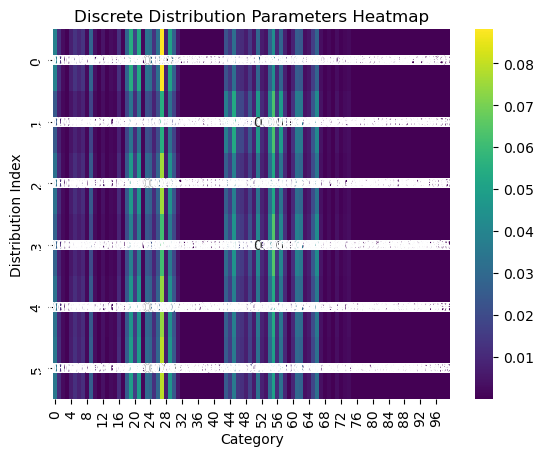

In [25]:
sns.heatmap(params.numpy(), cmap='viridis', annot=True, cbar=True)
plt.xlabel("Category")
plt.ylabel("Distribution Index")
plt.title("Discrete Distribution Parameters Heatmap")
plt.show()


In [26]:

true_params = data["word_dists"]
candidate_params = pyro.get_param_store().get_param("model_phi_u").detach()
# print(true_params.shape)
# print(candidate_params.shape)

# Normalize to make them valid distributions
true_params /= true_params.sum(dim=1, keepdim=True)
candidate_params /= candidate_params.sum(dim=1, keepdim=True)
assert torch.allclose(true_params.sum(dim=1), torch.ones_like(true_params.sum(dim=1)), atol=1e-4)
assert torch.allclose(candidate_params.sum(dim=1), torch.ones_like(candidate_params.sum(dim=1)), atol=1e-4)


# Compute Jensen-Shannon distance between all pairs
# def jensen_shannon(p, q, eps=1e-8):
#     # Normalize inputs to ensure valid distributions
#     p = p / (p.sum(dim=-1, keepdim=True) + eps)
#     q = q / (q.sum(dim=-1, keepdim=True) + eps)
#     m = 0.5 * (p + q)

#     # Compute KL divergences: kl_div expects log-prob as input
#     kl_pm = F.kl_div((p + eps).log(), m, reduction='none').sum(-1)
#     kl_qm = F.kl_div((q + eps).log(), m, reduction='none').sum(-1)

#     return 0.5 * (kl_pm + kl_qm)
def jensen_shannon(p, q, eps=1e-8):
    p = p / (p.sum(dim=-1, keepdim=True) + eps)
    q = q / (q.sum(dim=-1, keepdim=True) + eps)
    m = 0.5 * (p + q)

    kl_pm = (p * ((p + eps).log() - (m + eps).log())).sum(-1)
    kl_qm = (q * ((q + eps).log() - (m + eps).log())).sum(-1)

    return 0.5 * (kl_pm + kl_qm)
# Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

# print(similarity)

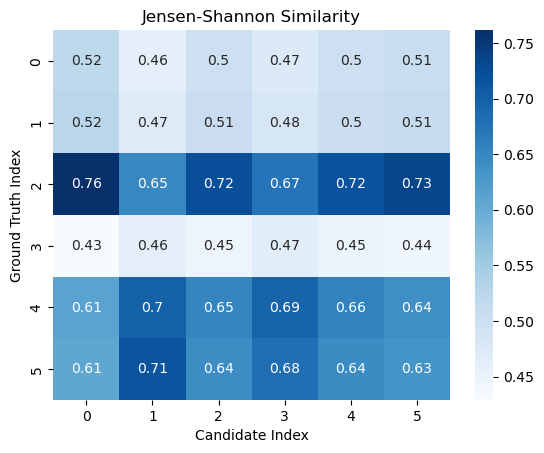

In [27]:
sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()


tensor([-1.5000, -0.9000, -0.3000,  0.3000,  0.9000,  1.5000])
tensor([-0.8570, -0.3355, -0.1414, -0.1407,  0.9346,  1.5500])
tensor([0.1145, 0.1210, 0.9430, 0.1320, 0.9437, 0.6983])


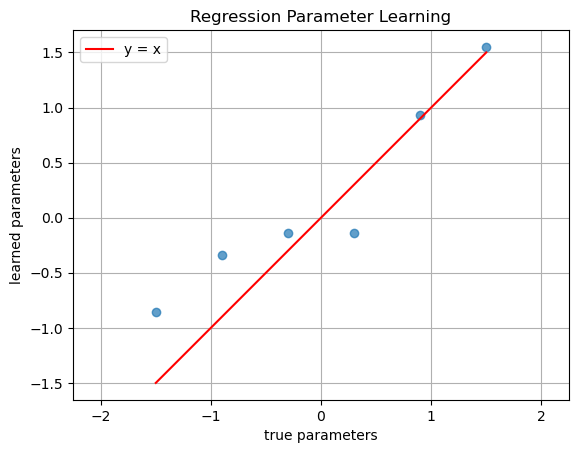

In [31]:
true_params = torch.linspace(-struct_upbd["G0"]/4, struct_upbd["G0"]/4, steps=struct_upbd["G0"]) 
candidate_params = candidate_params = pyro.get_param_store().get_param("model_phi_y_mu").detach()
# Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
p_exp = true_params
q_exp,  _ = torch.sort(candidate_params)
print(p_exp)
print(q_exp)
print(pyro.get_param_store().get_param("model_phi_y_sigma").detach())
plt.scatter(p_exp, q_exp, alpha=0.7)
plt.plot(true_params, true_params, label='y = x', color='red')
plt.xlabel('true parameters')
plt.ylabel('learned parameters')
plt.title('Regression Parameter Learning')
plt.legend()
plt.grid(True)
plt.axis('equal')  # keep aspect ratio square
plt.show()

In [32]:
from pyro.infer import Predictive

# guide: your trained guide
# model: your model without obs
# num_samples: number of predictive samples

predictive = Predictive(model, guide=guide, num_samples=100)

# Omit `data` or provide partial input depending on your model
samples = predictive((dataset[0].to(device), None),struct_upbd, vocab_size, device)  # or data=..., depending on your model's inputs

In [33]:
predict = samples['y'][-100:].mean(dim=0)
predict_var = samples['y'][-100:].var(dim=0)

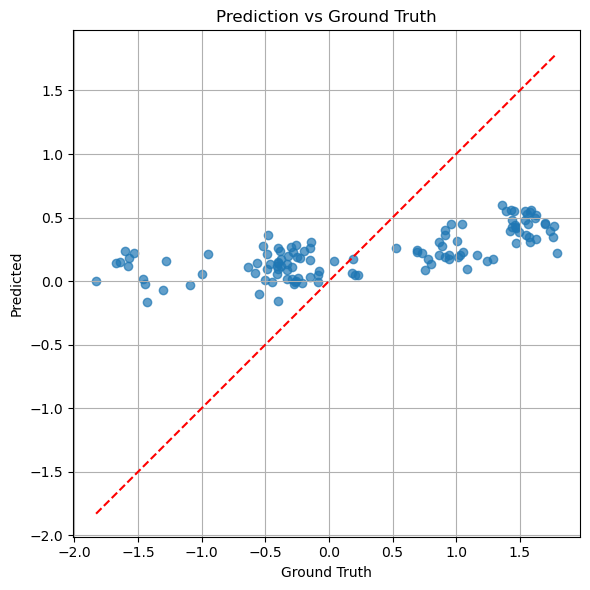

In [34]:
y_true = dataset[1]     # ground truth
y_pred = predict # predicted (with noise)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # y = x line
plt.xlabel("Ground Truth")
plt.ylabel("Predicted")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

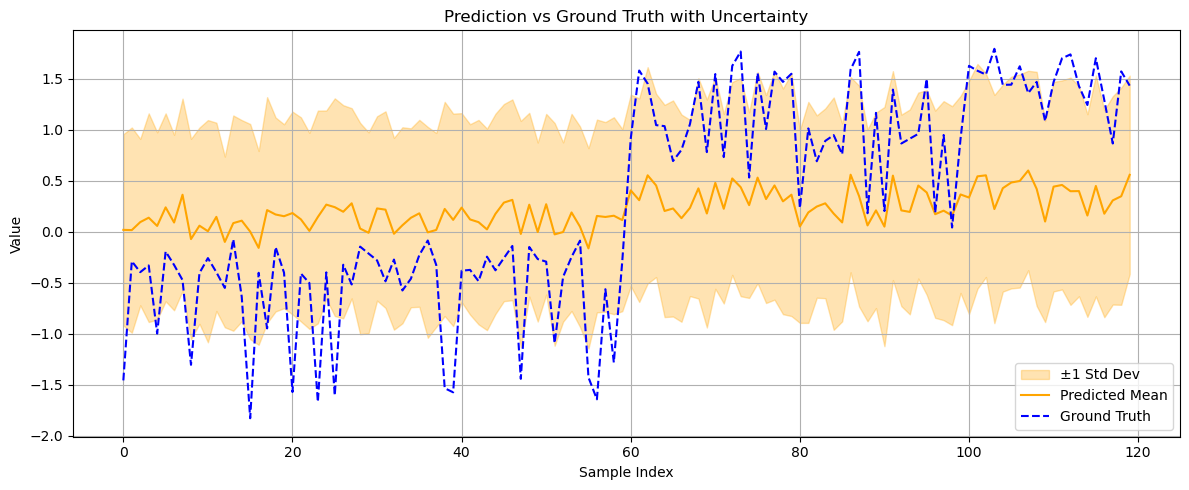

In [35]:
# Example data
N=120
mean_pred = y_pred
var_pred = predict_var

std_pred = var_pred.sqrt()
x = torch.arange(N)

plt.figure(figsize=(12, 5))

# Confidence interval (±1 std)
plt.fill_between(x, mean_pred - std_pred, mean_pred + std_pred, color="orange", alpha=0.3, label="±1 Std Dev")

# Prediction mean
plt.plot(x, mean_pred, color="orange", label="Predicted Mean")

# Ground truth
plt.plot(x, y_true, color="blue", linestyle="--", label="Ground Truth")

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Prediction vs Ground Truth with Uncertainty")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
predict_beta = samples['G2']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)

torch.Size([3, 2, 6])


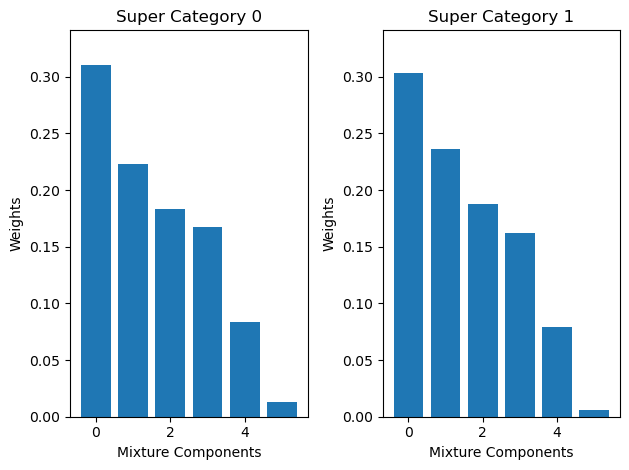

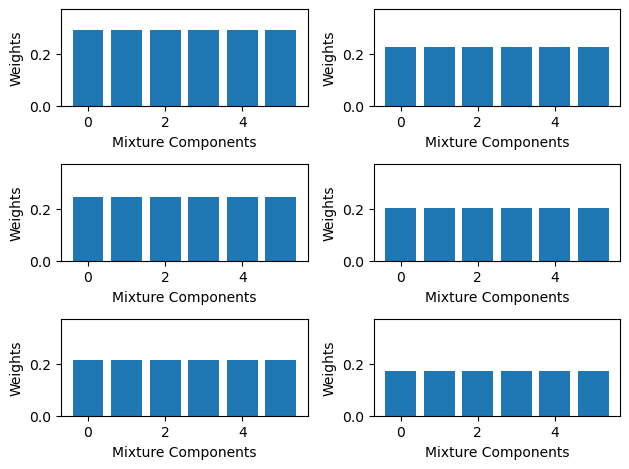

In [43]:
predict_beta = samples['G1']
weights = mix_weights(predict_beta)[..., :-1]
super_mix_weights = weights.mean(dim=0)
predict_beta = samples['G2']
weights = mix_weights(predict_beta)[..., :-1]
child_mix_weights = weights.mean(dim=0)
data = generate_hierarchical_mixture_data(struct_upbd)
fig, axs = plt.subplots(1, struct_upbd["G1"])
for i in range(struct_upbd["G1"]):
    ax = axs[i]
    ax.bar(range(struct_upbd["G0"]), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Super Category Weights of {struct_upbd['G0']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(struct_upbd["G2"], struct_upbd["G1"])
for i in range(struct_upbd["G2"]):
    for j in range(struct_upbd["G1"]):
        ax = axs[i, j]
        ax.bar(range(struct_upbd["G0"]), child_mix_weights[i][j].numpy())
        # ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Child Category Weights of {struct_upbd['G1']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

tensor([[0.7304, 0.6832, 0.7152, 0.6646, 0.7322, 0.6719],
        [0.7761, 0.7170, 0.7775, 0.7063, 0.7732, 0.7147],
        [0.7473, 0.6933, 0.7414, 0.6784, 0.7462, 0.6871],
        [0.4807, 0.6521, 0.4758, 0.6607, 0.4862, 0.6525],
        [0.5402, 0.6770, 0.5329, 0.6785, 0.5459, 0.6721],
        [0.4590, 0.6390, 0.4550, 0.6491, 0.4624, 0.6441]])


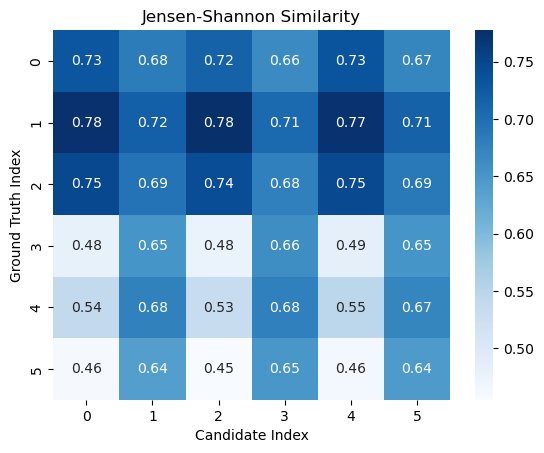

In [37]:
true_params = data["child_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = mean_w.reshape(-1, struct_upbd["G0"])

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

tensor([[1.0000, 0.9271, 0.9681, 0.3069, 0.3069, 0.3069],
        [0.9271, 1.0000, 0.9880, 0.3069, 0.3069, 0.3069],
        [0.9681, 0.9880, 1.0000, 0.3069, 0.3069, 0.3069],
        [0.3069, 0.3069, 0.3069, 1.0000, 0.9458, 0.9719],
        [0.3069, 0.3069, 0.3069, 0.9458, 1.0000, 0.8582],
        [0.3069, 0.3069, 0.3069, 0.9719, 0.8582, 1.0000]])


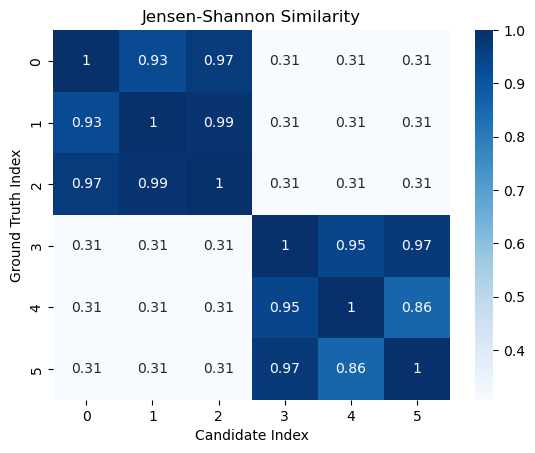

In [38]:
true_params = data["child_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = true_params

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

torch.Size([2, 6])
tensor([[0.7481, 0.7523],
        [0.5310, 0.5112]])


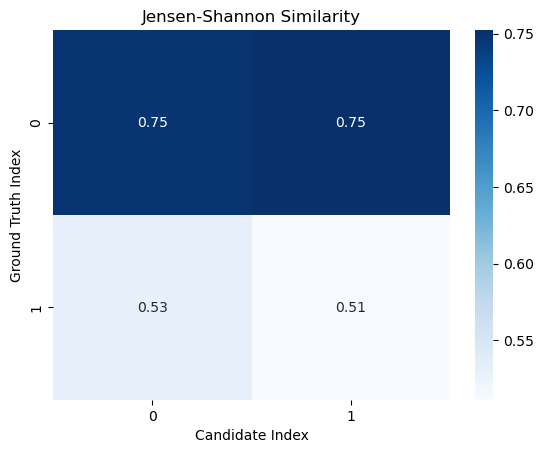

In [39]:
predict_beta = samples['G1']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)
true_params = data["super_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = mean_w.reshape(-1, struct_upbd["G0"])

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

torch.Size([2, 6])
tensor([[1.0000, 0.3069],
        [0.3069, 1.0000]])


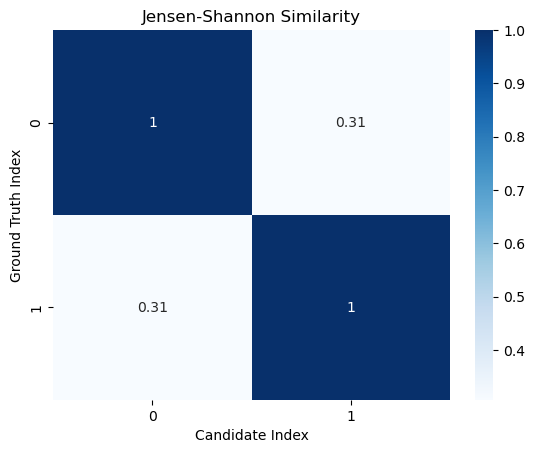

In [42]:
predict_beta = samples['G1']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)
true_params = data["super_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = true_params

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()